# 15-minute river station timeseries

Pulls the 15-minute instantaneous readings (temperature/flow/level) for each seeded station from Postgres and plots one figure per station, one subplot per parameter it carries.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wxdecide.database.engine import get_engine

%matplotlib inline

In [2]:
query = """
SELECT r.date_time, r.value, r.parameter, r.unit_name, s.label AS station_label, s.river_name
FROM readings r
JOIN stations s ON s.id = r.station_id
WHERE r.period_name = '15min'
ORDER BY s.label, r.parameter, r.date_time
"""

df = pd.read_sql_query(query, get_engine(), parse_dates=["date_time"])
df.groupby(["station_label", "river_name", "parameter"]).size()

station_label   river_name     parameter  
Boreton Bridge  Cound Brook    flow           28263
Bredon          River Avon     level          34927
Church Wilne    River Derwent  flow           28263
                               level          34928
Evesham         River Avon     flow           28263
                               level          34927
Littlethorpe    River Soar     TEMPERATURE    11655
                               flow           28263
                               level          34928
dtype: int64

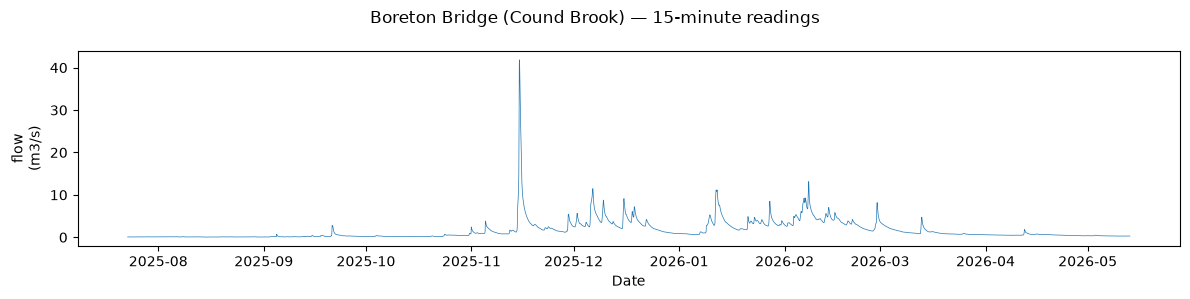

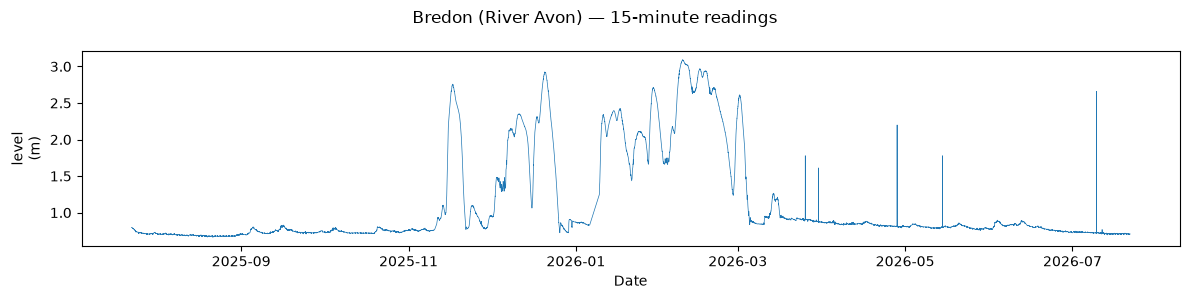

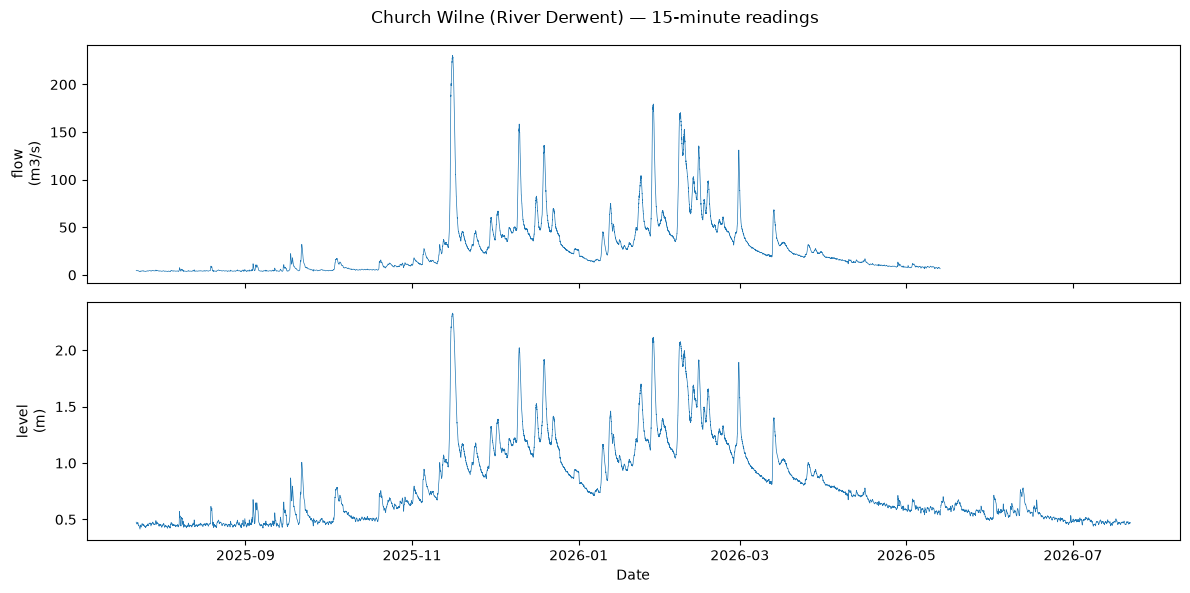

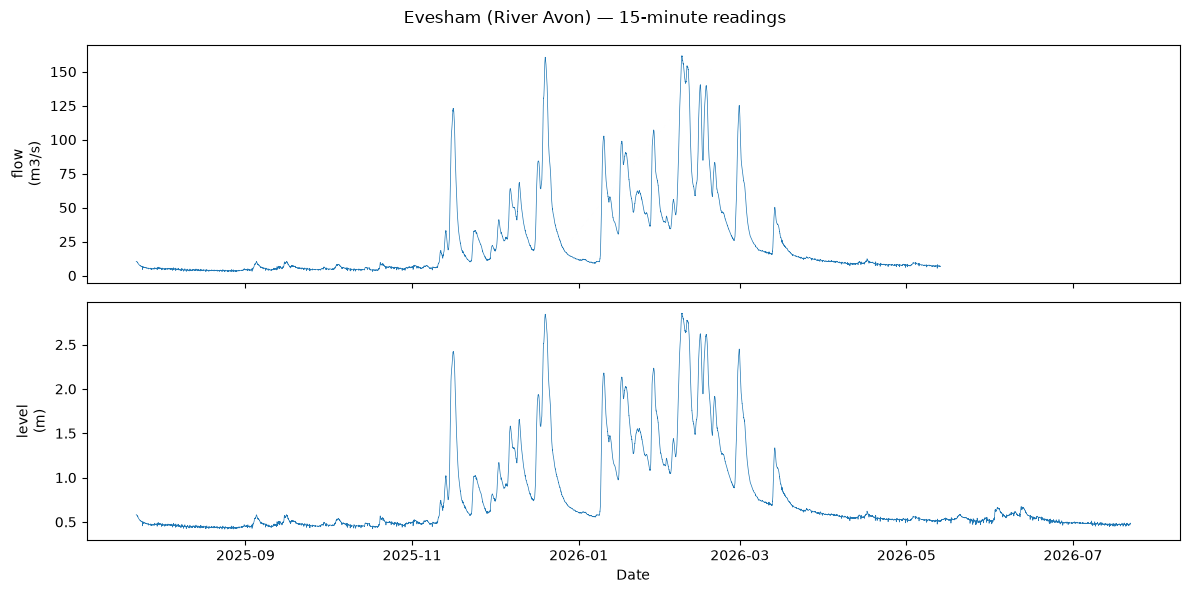

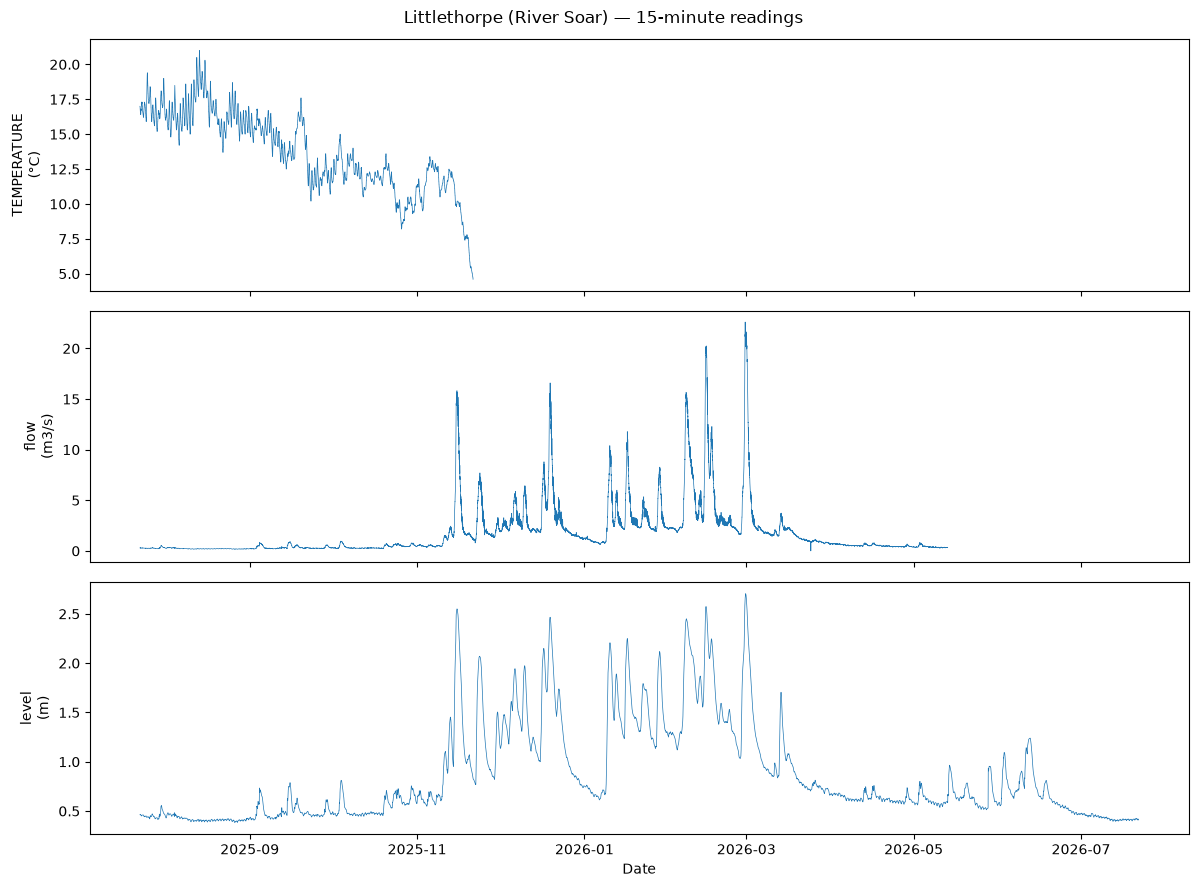

In [3]:
for station_label, station_df in df.groupby("station_label"):
    parameters = sorted(station_df["parameter"].unique())
    river_name = station_df["river_name"].iloc[0]

    fig, axes = plt.subplots(
        len(parameters), 1, figsize=(12, 3 * len(parameters)), sharex=True
    )
    axes = [axes] if len(parameters) == 1 else axes
    fig.suptitle(f"{station_label} ({river_name}) — 15-minute readings")

    for ax, parameter in zip(axes, parameters):
        param_df = station_df[station_df["parameter"] == parameter].sort_values("date_time")
        unit = param_df["unit_name"].iloc[0]
        ax.plot(param_df["date_time"], param_df["value"], linewidth=0.5)
        ax.set_ylabel(f"{parameter}\n({unit})")

    axes[-1].set_xlabel("Date")
    fig.tight_layout()
    plt.show()